## 0. Imports/Constants

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm
import glob

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.pfp import PFP
from sbnd.cafclasses.nu import NU
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import *
from sbnd.general import plotters
from naming import *
from sbnd.general.utils import read_hdf

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
# Fill these
checkpoint = 'checkpoint9_particle2'
VERSION = 'v10'
NCPU = 16
SMALL = 'cuts'
CONTAINED = True
CATEGORIES = [0]


PLOT_DIR = f'{DATA_DIR}/plots/{checkpoint}'
TABLE_DIR = f'{DATA_DIR}/tables/{checkpoint}'

#MC Fnames
# Use from syst files
MC_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_syst/{VERSION}/*_nosyst*/*.df'
)
# Use nominal
# MC_FNAMES = glob.glob(
#   f'{DATA_DIR}/det_var/nominal/{VERSION}/*_nominal*/*.df'
# )
# Use small file
# MC_FNAMES = glob.glob(
#   f'{DATA_DIR}/mc_syst/v9/mcbnb_smallpand_nosyst_nocuts_recomb.df'
# )
DATA_OFFBEAM_FNAMES = glob.glob(
  f'{DATA_DIR}/offbeam/{VERSION}/*data*/*.df'
)
DATA_FNAMES = glob.glob(
  f'{DATA_DIR}/data/{VERSION}/*dataonbeam*/*.df'
)
# DATA_FNAMES = glob.glob(
#   f'{DATA_DIR}/data/{VERSION}/dataonbeam_dev.df'
# )
MC_LOWE_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_lowe/{VERSION}/*_mclowe_*/*.df'
)

#Make copies to track original length
MC_FNAMES_FULL = MC_FNAMES.copy()
DATA_FNAMES_FULL = DATA_FNAMES.copy()
DATA_OFFBEAM_FNAMES_FULL = DATA_OFFBEAM_FNAMES.copy()
MC_LOWE_FNAMES_FULL = MC_LOWE_FNAMES.copy()

if SMALL == True:
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//30]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//30]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//30]
  cuts_to_apply = None
  cuts_in_chain = PAND_CUTS_CONT
elif SMALL == 'cuts':
  print('Warning: Cutting down on data for testing')
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//5]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//2]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//2]
  cuts_to_apply = PAND_CUTS_CONT.copy()
  #Remove the muon cut
  muon_ind = cuts_to_apply.index('muon')
  cuts_to_apply.pop(muon_ind)
  cuts_in_chain = ['muon'] #muon is last cut not applied
elif SMALL == False: #No cuts, but a lot of data
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//15]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//15]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//15]
  cuts_to_apply = None
  cuts_in_chain = PAND_CUTS_CONT

print('*' * 70)
print('checkpoint: ',checkpoint)
print('VERSION: ',VERSION)
print('NCPU: ',NCPU)
print('SMALL: ',SMALL)
print('CONTAINED: ',CONTAINED)
print('CATEGORIES: ',CATEGORIES)
print('PLOT_DIR: ',PLOT_DIR)
print('cuts_to_apply: ',cuts_to_apply)
print('cuts_in_chain: ',cuts_in_chain)
print('frac MC_FNAMES: ',len(MC_FNAMES)/len(MC_FNAMES_FULL))
print('frac DATA_OFFBEAM_FNAMES: ',len(DATA_OFFBEAM_FNAMES)/len(DATA_OFFBEAM_FNAMES_FULL))
print('frac DATA_FNAMES: ',len(DATA_FNAMES)/len(DATA_FNAMES_FULL))
print('frac MC_LOWE_FNAMES: ',len(MC_LOWE_FNAMES)/len(MC_LOWE_FNAMES_FULL))
print('MC_FNAMES[0]: ',MC_FNAMES[0])
print('DATA_OFFBEAM_FNAMES[0]: ',DATA_OFFBEAM_FNAMES[0])
print('DATA_FNAMES[0]: ',DATA_FNAMES[0])
print('MC_LOWE_FNAMES[0]: ',MC_LOWE_FNAMES[0])
print('*' * 70)

**********************************************************************
checkpoint:  checkpoint9_particle2
VERSION:  v10
NCPU:  16
SMALL:  cuts
CONTAINED:  True
CATEGORIES:  [0]
PLOT_DIR:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint9_particle2
cuts_to_apply:  ['flashpe', 'flashmatch', 'cosmic', 'fv', 'cont_full', 'cont', 'all_cont']
cuts_in_chain:  ['muon']
frac MC_FNAMES:  0.2
frac DATA_OFFBEAM_FNAMES:  0.5
frac DATA_FNAMES:  1.0
frac MC_LOWE_FNAMES:  0.5
MC_FNAMES[0]:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v10/2026_06_23_115539__nosyst_nocuts_recomb_mcbnb_largepand_nosyst_nocuts_recomb/nosyst_nocuts_recomb_mcbnb_largepand_nosyst_nocuts_recomb_414.df
DATA_OFFBEAM_FNAMES[0]:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/offbeam/v10/2026_06_23_130111__nosyst_nocuts_recomb_data_large/nosyst_nocuts_recomb_data_large_9.df
DATA_FNAMES[0]:  /exp/sbnd/data/users/brin

## 1. Load data

In [53]:
POT_LOWE = read_hdf(MC_LOWE_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
POT_MC = read_hdf(MC_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
LIVETIME_OFFBEAM = read_hdf(DATA_OFFBEAM_FNAMES,key=HDR_KEY, ncpu=NCPU, show_progress=True).noffbeambnb.values.sum()
POT_DATA = read_hdf(DATA_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
LIVETIME_DATA = 9.51e5*POT_DATA/4.58e18 # Temporary override
POT_LABEL = f'{POT_DATA:.2e} POT'
print(f'POT_LOWE: {POT_LOWE:.2e}')
print(f'POT_MC: {POT_MC:.2e}')
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
print(f'POT_LABEL: {POT_LABEL}')

read_hdf: 100%|██████████| 100/100 [00:06<00:00, 15.53it/s]


POT_LOWE: 1.14e+20
POT_MC: 1.12e+20
LIVETIME_OFFBEAM: 4.17e+07
LIVETIME_DATA: 9.50e+05
POT_LABEL: 4.57e+18 POT


In [ ]:
# Get slices (apply cosmic cuts)
slc_mc = CAFSlice.load(MC_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=cuts_to_apply is None
)
slc_lowe = CAFSlice.load(MC_LOWE_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=cuts_to_apply is None
)
slc_offbeam = CAFSlice.load(DATA_OFFBEAM_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=cuts_to_apply is None
)
slc_data = CAFSlice.load(DATA_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=cuts_to_apply is None
)
for s in [slc_mc,slc_lowe,slc_offbeam,slc_data]:
  s.cut_is_cont(cut=False) # Add cont_full cut

# Get mcnu
mcnu = NU.load(MC_FNAMES,
  key=MCNU_KEY,
  ncpu=NCPU,
  show_progress=cuts_to_apply is None
)
mcnu_lowe = NU.load(MC_LOWE_FNAMES,
  key=MCNU_KEY,
  ncpu=NCPU,
  show_progress=cuts_to_apply is None
)


In [ ]:
# Get pfps
trk_mc = PFP.load(MC_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)
trk_lowe = PFP.load(MC_LOWE_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)
trk_offbeam = PFP.load(DATA_OFFBEAM_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)
trk_data = PFP.load(DATA_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)

Loading combined CAF:  70%|███████   | 140/200 [00:16<00:03, 16.32it/s]

Loading combined CAF: 100%|██████████| 100/100 [00:19<00:00,  5.05it/s]


### 1.1 Scale samples

In [ ]:
slc_mc.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)
slc_lowe.scale_to_pot(POT_DATA,sample_pot=POT_LOWE,overwrite=True)
slc_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,f=F_SCALE,overwrite=True)

trk_mc.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)
trk_lowe.scale_to_pot(POT_DATA,sample_pot=POT_LOWE,overwrite=True)
trk_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,f=F_SCALE,overwrite=True)

POT_LABEL

--scaling to POT (4.07e-02): 1.12e+20 -> 4.57e+18
--scaling to POT (4.01e-02): 1.14e+20 -> 4.57e+18
--scaling to livetime (2.11e-02): 4.17e+07 --> 9.50e+05
---scale factor without f: 2.2760e-02
--- f: 0.0725
--scaling to POT (4.07e-02): 1.12e+20 -> 4.57e+18
--scaling to POT (4.01e-02): 1.14e+20 -> 4.57e+18
--scaling to livetime (2.11e-02): 4.17e+07 --> 9.50e+05
---scale factor without f: 2.2760e-02
--- f: 0.0725


'4.57e+18 POT'

### 1.2 Combine the offbeam to the MC sample

In [ ]:
slc_mc.combine(slc_offbeam,duplicate_ok=True,offset=int(1e6))
del slc_offbeam
slc_mc.combine(slc_lowe,duplicate_ok=True,offset=int(2e6))
del slc_lowe

trk_mc.combine(trk_offbeam,duplicate_ok=True,offset=int(1e6))
del trk_offbeam
trk_mc.combine(trk_lowe,duplicate_ok=True,offset=int(2e6))
del trk_lowe

In [ ]:
mcnu.combine(mcnu_lowe,duplicate_ok=True)
del mcnu_lowe

## 2. BCFM plots

### 2.1 Break into lists of objects

In [13]:
slcs = []

#Get event type col
slc_event_type_col = slc_mc.get_key('truth.event_type')

# Group data by event type once
slc_groups = slc_mc.data.groupby(slc_event_type_col)

#Create objects only for groups that exist
for key,val in EVENT_TYPE_LIST.items():
  if key in slc_groups.groups:
    slcs.append(CAFSlice(slc_groups.get_group(key)))

/tmp/ipykernel_14240/3773502384.py:12: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  slcs.append(CAFSlice(slc_groups.get_group(key)))


In [14]:
#Get label info
labels = []
names = []
colors = []

for key,item in EVENT_TYPE_LIST.items():
  if key == -1:# or key == 4: #Skip nuecc since it's not in small sample
    continue
  labels.append(item[0])
  names.append(item[1])
  colors.append(item[2])

slc_weights = [s.data.genweight for s in slcs]
assert [any(np.isnan(sw)) or any(np.isinf(sw)) for sw in slc_weights].count(True) == 0


In [15]:
labels

['$\\nu_\\mu$ CC (cont.)',
 '$\\nu_\\mu$ CC (exit.)',
 '$\\nu_\\mu$ CC (OOPS)',
 'Non-AV',
 '$\\nu_e$ CC',
 '$\\nu$ NC',
 'Cosmic']

### 2.2 Make the plots

In [16]:
from sbnd.plotlibrary import makeplot
from sbnd.general import plotters
from naming import PANDORA_QUALIFIER_INTERNAL_LABEL

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()


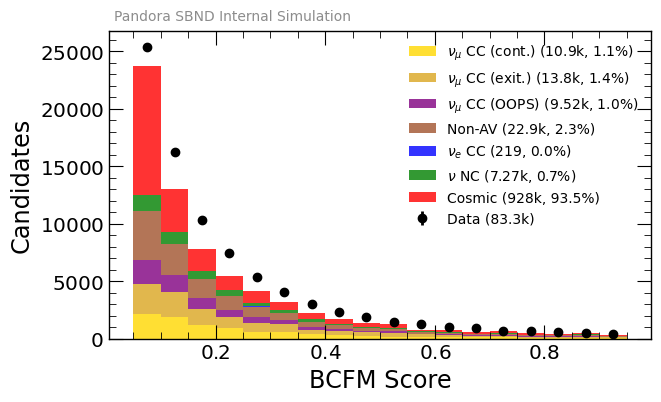

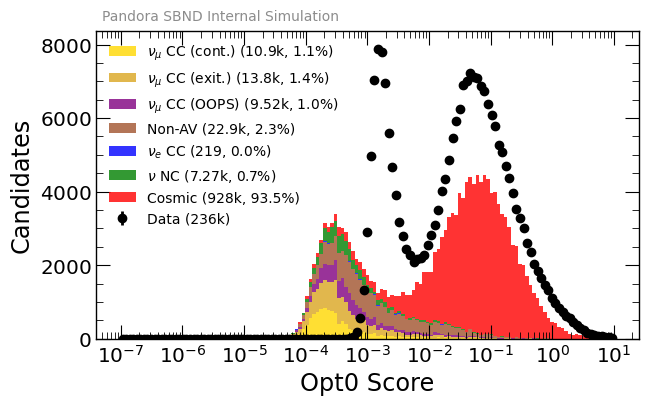

In [17]:
bcfm_score = [s.data.slc.barycenterFM.score for s in slcs]
opt0_score = [1/s.data.slc.opt0.score for s in slcs]

bcfm_score_data = slc_data.data.slc.barycenterFM.score
opt0_score_data = 1/slc_data.data.slc.opt0.score

bcfm_bins = np.arange(0.05,1.,0.05)
opt0_bins = np.logspace(-7,1,140)

fig,ax = makeplot.create_hist(
    bcfm_score, 
    labels,
    dens=False,
    bins=bcfm_bins,
    data_series=bcfm_score_data,
    weights=slc_weights,
    cut_desc='',
    xlabel='BCFM Score',
    colors=colors,
    label=PANDORA_QUALIFIER_INTERNAL_LABEL,
)

fig,ax = makeplot.create_hist(
    opt0_score, 
    labels,
    dens=False,
    bins=opt0_bins,
    data_series=opt0_score_data,
    weights=slc_weights,
    cut_desc='',
    xlabel='Opt0 Score',
    colors=colors,
    savename='',
    label=PANDORA_QUALIFIER_INTERNAL_LABEL,
)
ax.set_xscale('log')
fig.show()

In [18]:
#Ok, let's plot pur and eff as function of bcfm score
bcfm_scores = np.linspace(0,0.2,41)
#bcfm_scores = [0.0,1.]
_slc_mc = slc_mc.copy()
#_slc_mc_base.cut_flashmatch(method='barycenterFM',use_isclearcosmic=False,cut=False)

bcfm_purs = []
bcfm_effs = []
bcfm_f1s = []

for score in tqdm(bcfm_scores,unit=' goomba'):
  _slc_mc.cut_cosmic(fmatch_score=score,use_opt0='barycenterFM',nu_score=0.0,use_isclearcosmic=True,cut=False)
  #print(np.sum(_slc_mc.data.cut.cosmic))
  pur,eff,f1,_,_,_ = _slc_mc.get_pur_eff_f1(mcnu,['flashmatch','cosmic'],categories=[0,1])
  bcfm_purs.append(pur)
  bcfm_effs.append(eff)
  bcfm_f1s.append(f1)

 61%|██████    | 25/41 [14:24<09:13, 34.58s/ goomba]


KeyboardInterrupt: 

In [ ]:
#opt0_scores = np.logspace(-3,-2,20)
opt0_scores = np.logspace(-4,-1,41)
opt0_purs = []
opt0_effs = []
opt0_f1s = []
_slc_mc = slc_mc.copy()
_slc_mc.cut_flashmatch(method='opt0',cut=False,use_isclearcosmic=False)

for score in tqdm(opt0_scores,unit=' goomba'):
  #_slc_mc = _slc_mc.copy()
  #_slc_mc.data.cut.cosmic = False
  #print(np.sum(_slc_mc.data.cut.cosmic))
  _slc_mc.cut_cosmic(fmatch_score=1/score,use_opt0=True,nu_score=0.0,use_isclearcosmic=False,cut=False)
  #print(np.sum(_slc_mc.data.cut.cosmic))
  pur,eff,f1,_,_,_ = _slc_mc.get_pur_eff_f1(mcnu,['flashmatch','cosmic'],categories=[0,1])
  opt0_purs.append(pur)
  opt0_effs.append(eff)
  opt0_f1s.append(f1)

100%|██████████| 41/41 [04:46<00:00,  7.00s/ goomba]


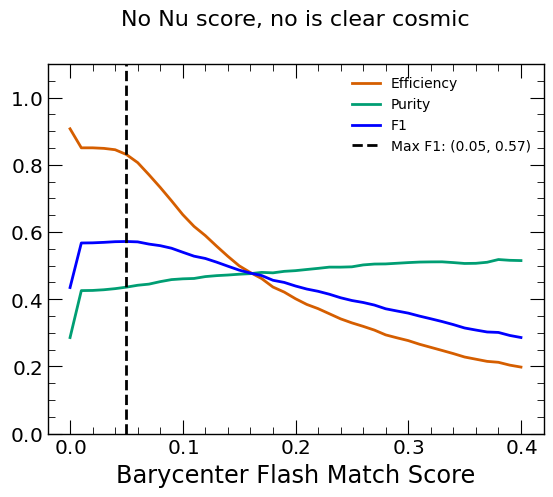

In [ ]:
fig,ax = plt.subplots()

ax.plot(bcfm_scores,[p[-1] for p in bcfm_effs],label='Efficiency')
ax.plot(bcfm_scores,[p[-1] for p in bcfm_purs],label='Purity')
ax.plot(bcfm_scores,[p[-1] for p in bcfm_f1s],label='F1',color='blue')

ax.axvline(bcfm_scores[np.argmax([p[-1] for p in bcfm_f1s])],ls='--',color='k',
  label=f'Max F1: ({bcfm_scores[np.argmax([p[-1] for p in bcfm_f1s])]:.2f}, {max([p[-1] for p in bcfm_f1s]):.2f})')
#ax.axhline(np.max([p[-1] for p in bcfm_f1s]),ls='--',color='k')

ax.legend()
ax.set_xlabel('Barycenter Flash Match Score')
ax.set_ylim(0,1.1)
ax.set_title('No Nu score, no is clear cosmic',fontsize=16)
plotters.save_plot('bcfm_pureff.png',fig=fig,folder_name=f'{PLOT_DIR}/fmatch')

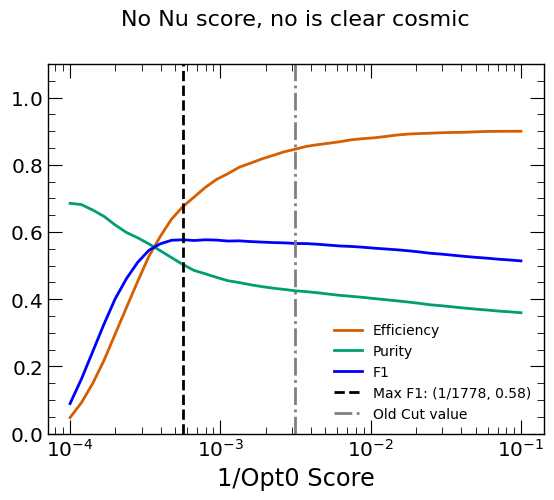

In [ ]:
fig,ax2 = plt.subplots()

ax2.plot(opt0_scores,[p[-1] for p in opt0_effs],label='Efficiency')
ax2.plot(opt0_scores,[p[-1] for p in opt0_purs],label='Purity')
ax2.plot(opt0_scores,[p[-1] for p in opt0_f1s],label='F1',color='blue')
ax2.axvline(opt0_scores[np.argmax([p[-1] for p in opt0_f1s])],ls='--',color='k',
  label=f'Max F1: (1/{1/opt0_scores[np.argmax([p[-1] for p in opt0_f1s])]:.0f}, {max([p[-1] for p in opt0_f1s]):.2f})')
ax2.axvline(1/320,ls='-.',color='gray',label='Old Cut value')

ax2.legend()
ax2.set_xscale('log')
ax2.set_xlabel('1/Opt0 Score')
ax2.set_ylim(0,1.1)
ax2.set_title('No Nu score, no is clear cosmic',fontsize=16)
plotters.save_plot('opt0_pureff.png',fig=fig,folder_name=f'{PLOT_DIR}/fmatch')

## 3. Track plots

### 3.0 Apply cuts to reduce to neutrino candidates

In [ ]:
slc_mc_nocosmic = slc_mc.copy()
slc_data_nocosmic = slc_data.copy()

In [68]:
from sbnd.detector.volume import *
DO_LEN_CUT = False
contained = True
midz_lowy_volume = None
highx_lowz_volume = None
highy_lowz_volume = None
x_fiducial_cm = X_FIDUCIAL_CM
x_cathode_cm = X_CATHODE_CM
INVERT_VOLUME = False

MIDZ_VOLUMES = {1: NOT_FV_MIDZ_LOWY1, 2: NOT_FV_MIDZ_LOWY2, 3: NOT_FV_MIDZ_LOWY3}
HIGHX_VOLUMES = {1: NOT_FV_HIGHX_LOWZ1, 2: NOT_FV_HIGHX_LOWZ2, 3: NOT_FV_HIGHX_LOWZ3, 4: NOT_FV_HIGHX_LOWZ4}
HIGHY_VOLUMES = {1: NOT_FV_HIGHY_LOWZ1, 2: NOT_FV_HIGHY_LOWZ2}

def resolve_volume(mask_id, volume_map, name):
  if mask_id is None:
    return None
  if mask_id not in volume_map:
    raise ValueError(f'{name} must be one of {sorted(volume_map)}, got {mask_id}')
  return volume_map[mask_id]

def volume_folder_suffix(base, mask_id):
  if INVERT_VOLUME:
    return f'_{base}invert{mask_id}'
  return f'_{base}{mask_id}'

def track_volume_mask(start, end, *, volume, cont_kwargs):
  if INVERT_VOLUME and volume is not None:
    return enters(start, end, volume)
  return (
    track_cont_tpc0(start, end, **cont_kwargs)
    | track_cont_tpc1(start, end, **cont_kwargs)
  )

#Set bin sizes based on data size
BIN_CUTOFF = 1000
bin_dict = {
  'small': {
    'len': np.arange(0,450,10),  #use small when there is a little data
    'chi2_muon': np.arange(0,61,1), 
    'chi2_proton': np.arange(0,305,5), 
    'score': np.arange(0,1.025,0.025)},
  'large': {
    'len': np.arange(0,450,20),  #use large when there is a lot of data
    'chi2_muon': np.arange(0,61,2),
    'chi2_proton': np.arange(0,305,10),
    'score': np.arange(0,1.05,0.05)},
}

for DO_LEN_CUT in [False,True]:
  for INVERT_VOLUME in [False,True]:
    for midz_lowy_volume in [2,None]:
      for highx_lowz_volume in [None]:
        for highy_lowz_volume in [1,None]:
          for x_fiducial_cm in [190,180]:
            for x_cathode_cm in [5]:
              print('*'*50)
              _active_veto_masks = [
                name for name, val in [
                  ('midz', midz_lowy_volume),
                  ('highx', highx_lowz_volume),
                  ('highy', highy_lowz_volume),
                ] if val is not None
              ]
              if INVERT_VOLUME and len(_active_veto_masks) > 1:
                print(
                  f'SKIP: multiple volume masks active: {_active_veto_masks} '
                  f'(midz={midz_lowy_volume}, highx={highx_lowz_volume}, highy={highy_lowz_volume})'
                )
                continue

              _midz_vol = resolve_volume(midz_lowy_volume, MIDZ_VOLUMES, 'midz_lowy_volume')
              _highx_vol = resolve_volume(highx_lowz_volume, HIGHX_VOLUMES, 'highx_lowz_volume')
              _highy_vol = resolve_volume(highy_lowz_volume, HIGHY_VOLUMES, 'highy_lowz_volume')
              _invert_vol = _midz_vol or _highx_vol or _highy_vol

              cont_kwargs = {
                'midz_lowy_veto': _midz_vol is not None and not INVERT_VOLUME,
                'midz_lowy_volume': _midz_vol or NOT_FV_MIDZ_LOWY2,
                'highx_lowz_veto': _highx_vol is not None and not INVERT_VOLUME,
                'highx_lowz_volume': _highx_vol or NOT_FV_HIGHX_LOWZ3,
                'highy_lowz_veto': _highy_vol is not None and not INVERT_VOLUME,
                'highy_lowz_volume': _highy_vol or NOT_FV_HIGHY_LOWZ2,
                'x_fiducial_cm': x_fiducial_cm,
                'x_cathode_cm': x_cathode_cm,
              }

              folder = 'nomuoncut'
              save_suffix = ''
              title = 'No Muon Cuts'
              if midz_lowy_volume is not None:
                folder += volume_folder_suffix('midz', midz_lowy_volume)
              if highx_lowz_volume is not None:
                folder += volume_folder_suffix('highx', highx_lowz_volume)
              if highy_lowz_volume is not None:
                folder += volume_folder_suffix('highylowz', highy_lowz_volume)
              if x_cathode_cm != X_CATHODE_CM:
                folder += f'_xc{x_cathode_cm}'
              if x_fiducial_cm != X_FIDUCIAL_CM:
                folder += f'_xf{x_fiducial_cm}'

              trk_mc_nocosmic = trk_mc.copy()
              trk_mc_nocosmic.data = slc_mc_nocosmic.get_reference_df(trk_mc_nocosmic)

              trk_data_nocosmic = trk_data.copy()
              trk_data_nocosmic.data = slc_data_nocosmic.get_reference_df(trk_data_nocosmic)

              start_mc_nocosmic = trk_mc_nocosmic.data.pfp.trk.start
              end_mc_nocosmic = trk_mc_nocosmic.data.pfp.trk.end
              start_data_nocosmic = trk_data_nocosmic.data.pfp.trk.start
              end_data_nocosmic = trk_data_nocosmic.data.pfp.trk.end

              m = trk_mc_nocosmic.data.pfp.trackScore > 0.6
              if DO_LEN_CUT:
                m &= trk_mc_nocosmic.data.pfp.trk.len > 32
              m &= trk_mc_nocosmic.data.pfp.trk.cont_tpc0.values.astype(bool) | trk_mc_nocosmic.data.pfp.trk.cont_tpc1.values.astype(bool)
              print('MC length before volume cut: ',m.sum())
              m &= track_volume_mask(
                start_mc_nocosmic, end_mc_nocosmic,
                volume=_invert_vol, cont_kwargs=cont_kwargs,
              )
              print('MC length after volume cut: ',m.sum())
              trk_mc_nocosmic.data = trk_mc_nocosmic.data[m]

              m = trk_data_nocosmic.data.pfp.trackScore > 0.6
              if DO_LEN_CUT:
                m &= trk_data_nocosmic.data.pfp.trk.len > 32
                title += ', L > 32 cm'
                save_suffix += '_len'
              m &= trk_data_nocosmic.data.pfp.trk.cont_tpc0.values.astype(bool) | trk_data_nocosmic.data.pfp.trk.cont_tpc1.values.astype(bool)
              print('Data length before volume cut: ',m.sum())
              m &= track_volume_mask(
                start_data_nocosmic, end_data_nocosmic,
                volume=_invert_vol, cont_kwargs=cont_kwargs,
              )
              print('Data length after volume cut: ',m.sum())
              trk_data_nocosmic.data = trk_data_nocosmic.data[m]

              #Set binnings
              if trk_mc_nocosmic.data.shape[0] > BIN_CUTOFF:
                bin_dict_use = bin_dict['large']
              else:
                bin_dict_use = bin_dict['small']

              print(f'Folder: {folder}')

              trks = []

              trk_mc_nocosmic.add_cols('pfp.trk.truth.p.abspdg',np.abs(trk_mc_nocosmic.data.pfp.trk.truth.p.pdg.values),fill=np.int32(0))
              trk_true_particle = trk_mc_nocosmic.get_key('pfp.trk.truth.p.abspdg')

              trk_groups = trk_mc_nocosmic.data.groupby(trk_true_particle)
              missing_keys = []

              for key,val in PARTICLE_TYPE_LIST.items():
                if key in trk_groups.groups:
                  trks.append(PFP(trk_groups.get_group(key)))
                else:
                  missing_keys.append(key)

              labels = []
              names = []
              colors = []

              for key,item in PARTICLE_TYPE_LIST.items():
                if key in missing_keys:
                  continue
                labels.append(item[0])
                names.append(item[1])
                colors.append(item[2])

              trk_weights = [s.data.genweight for s in trks]
              assert [any(np.isnan(tw)) for tw in trk_weights].count(True) == 0

              from sbnd.numu.numu_constants import *
              chi2_bins = np.arange(0,150,2)

              chi2_muons = [t.data.pfp.trk.chi2pid.I2.chi2_muon for t in trks]
              chi2_protons = [t.data.pfp.trk.chi2pid.I2.chi2_proton for t in trks]
              trk_scores = [t.data.pfp.trackScore for t in trks]
              trk_lens = [t.data.pfp.trk.len for t in trks]

              chi2_muons_data = trk_data_nocosmic.data.pfp.trk.chi2pid.I2.chi2_muon
              chi2_protons_data = trk_data_nocosmic.data.pfp.trk.chi2pid.I2.chi2_proton
              trk_scores_data = trk_data_nocosmic.data.pfp.trackScore
              trk_lens_data = trk_data_nocosmic.data.pfp.trk.len

              fig,ax,ax2 = makeplot.create_hist_dataratio(
                  trk_lens,
                  labels,
                  dens=False,
                  bins=bin_dict_use['len'],
                  data_series=trk_lens_data,
                  weights=trk_weights,
                  cut_desc='',
                  xlabel='Track Length',
                  colors=colors,
                  label=PANDORA_QUALIFIER_INTERNAL_LABEL,
                  pot_label=POT_LABEL,
                  savename=f'stacked_track_length_{save_suffix}',
                  title=title,
                  plot_dir=f'{PLOT_DIR}/{folder}',
                  ylim=(0.5,1.5)
                  )
              fig,ax,ax2 = makeplot.create_hist_dataratio(
                  chi2_muons,
                  labels,
                  dens=False,
                  bins = bin_dict_use['chi2_muon'],
                  data_series=chi2_muons_data,
                  weights=trk_weights,
                  cut_desc='',
                  xlabel=r'$\chi^2$ Muon',
                  colors=colors,
                  label=PANDORA_QUALIFIER_INTERNAL_LABEL,
                  pot_label=POT_LABEL,
                  savename=f'stacked_chi2_muon_{save_suffix}',
                  title=title,
                  plot_dir=f'{PLOT_DIR}/{folder}',
                  ylim=(0,2)
              )

              fig,ax,ax2 = makeplot.create_hist_dataratio(
                  chi2_protons,
                  labels,
                  dens=False,
                  bins = bin_dict_use['chi2_proton'],
                  data_series=chi2_protons_data,
                  weights=trk_weights,
                  cut_desc='',
                  xlabel=r'$\chi^2$ Proton',
                  colors=colors,
                  label=PANDORA_QUALIFIER_INTERNAL_LABEL,
                  pot_label=POT_LABEL,
                  savename=f'stacked_chi2_proton_{save_suffix}',
                  plot_dir=f'{PLOT_DIR}/{folder}',
                  title=title,
                  ylim=(0,2)
              )

              # fig,ax,ax2 = makeplot.create_hist_dataratio(
              #     trk_scores,
              #     labels,
              #     dens=False,
              #     bins=bin_dict_use['score'],
              #     data_series=trk_scores_data,
              #     weights=trk_weights,
              #     cut_desc='',
              #     xlabel='Track Score',
              #     colors=colors,
              #     label=PANDORA_QUALIFIER_INTERNAL_LABEL,
              #     pot_label=POT_LABEL,
              #     savename=f'stacked_track_score',
              #     plot_dir=f'{PLOT_DIR}/{folder}/track_score',
              #     title=title
              # )

**************************************************


MC length before volume cut:  143227
MC length after volume cut:  124051
Data length before volume cut:  6548
Data length after volume cut:  5462
Folder: nomuoncut_midz2_highylowz1


/tmp/ipykernel_49832/740004566.py:157: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  trks.append(PFP(trk_groups.get_group(key)))
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

**************************************************
MC length before volume cut:  143227
MC length after volume cut:  117589
Data length before volume cut:  6548
Data length after volume cut:  5105
Folder: nomuoncut_midz2_highylowz1_xf180


/tmp/ipykernel_49832/740004566.py:157: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  trks.append(PFP(trk_groups.get_group(key)))
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

...

/tmp/ipykernel_49832/740004566.py:157: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  trks.append(PFP(trk_groups.get_group(key)))
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

**************************************************
MC length before volume cut:  108802
MC length after volume cut:  108802
Data length before volume cut:  5135
Data length after volume cut:  5135
Folder: nomuoncut


/tmp/ipykernel_49832/740004566.py:157: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  trks.append(PFP(trk_groups.get_group(key)))
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

**************************************************
MC length before volume cut:  108802
MC length after volume cut:  102480
Data length before volume cut:  5135
Data length after volume cut:  4782
Folder: nomuoncut_xf180


/tmp/ipykernel_49832/740004566.py:157: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  trks.append(PFP(trk_groups.get_group(key)))
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

### 3.1 Break into lists of objects

/tmp/ipykernel_49832/399178477.py:14: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  trks.append(PFP(trk_groups.get_group(key)))


In [39]:
from sbnd.constants import *

### 3.2 Make the plots

In [41]:
from sbnd.plotlibrary import makeplot
from naming import *

In [43]:
PLOT_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint9_particle'

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = np.array(data_series.groupby(pd.cut(data_series,bins=bins)).count().values,dtype=np.float32)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:616: RuntimeWarning: invalid va

### 3.3 Plot unstacked histograms with variations and data

In [28]:
#Alpha variables - muon
alpha_muon_keys = ['pfp.trk.chi2pid.I2.chi2_muon_alpha_embm1',
              'pfp.trk.chi2pid.I2.chi2_muon_alpha_embp1',
              'pfp.trk.chi2pid.I2.chi2_muon',
              ]
alpha_muon_cols = trk_mc_nocosmic.get_key(alpha_muon_keys)
alpha_proton_keys = ['pfp.trk.chi2pid.I2.chi2_proton_alpha_embm1',
              'pfp.trk.chi2pid.I2.chi2_proton_alpha_embp1',
              'pfp.trk.chi2pid.I2.chi2_proton',
              ]
alpha_proton_cols = trk_mc_nocosmic.get_key(alpha_proton_keys)

alpha_labels = [r'$\alpha - 1\sigma$',r'$\alpha + 1\sigma$',r'CV']

#Beta variables - muon
beta_muon_keys = ['pfp.trk.chi2pid.I2.chi2_muon_beta_90m1',
             'pfp.trk.chi2pid.I2.chi2_muon_beta_90p1',
             'pfp.trk.chi2pid.I2.chi2_muon',
             ]
beta_muon_cols = trk_mc_nocosmic.get_key(beta_muon_keys)
beta_proton_keys = ['pfp.trk.chi2pid.I2.chi2_proton_beta_90m1',
             'pfp.trk.chi2pid.I2.chi2_proton_beta_90p1',
             'pfp.trk.chi2pid.I2.chi2_proton',
             ]
beta_proton_cols = trk_mc_nocosmic.get_key(beta_proton_keys)
beta_labels = [r'$\beta - 1\sigma$',r'$\beta + 1\sigma$',r'CV']

#Recombination variables
r_muon_keys = ['pfp.trk.chi2pid.I2.chi2_muon_R_embm1',
              'pfp.trk.chi2pid.I2.chi2_muon_R_embp1',
              'pfp.trk.chi2pid.I2.chi2_muon',
              ]
r_muon_cols = trk_mc_nocosmic.get_key(r_muon_keys)
r_proton_keys = ['pfp.trk.chi2pid.I2.chi2_proton_R_embm1',
              'pfp.trk.chi2pid.I2.chi2_proton_R_embp1',
              'pfp.trk.chi2pid.I2.chi2_proton',]
r_proton_cols = trk_mc_nocosmic.get_key(r_proton_keys)
r_labels = [r'$R - 1\sigma$',r'$R + 1\sigma$',r'CV']

#Gain variables
gain_muon_keys = ['pfp.trk.chi2pid.I2.chi2_muon_c_cal_fracm1',
                  'pfp.trk.chi2pid.I2.chi2_muon_c_cal_fracp1',
                  'pfp.trk.chi2pid.I2.chi2_muon',
                  ]
gain_muon_cols = trk_mc_nocosmic.get_key(gain_muon_keys)
gain_proton_keys = ['pfp.trk.chi2pid.I2.chi2_proton_c_cal_fracm1',
                   'pfp.trk.chi2pid.I2.chi2_proton_c_cal_fracp1',
                   'pfp.trk.chi2pid.I2.chi2_proton',
                   ]
gain_proton_cols = trk_mc_nocosmic.get_key(gain_proton_keys)
gain_labels = [r'$C_{gain} - 1\sigma$',r'$C_{gain} + 1\sigma$',r'CV']

colors = ['blue','orange','green']

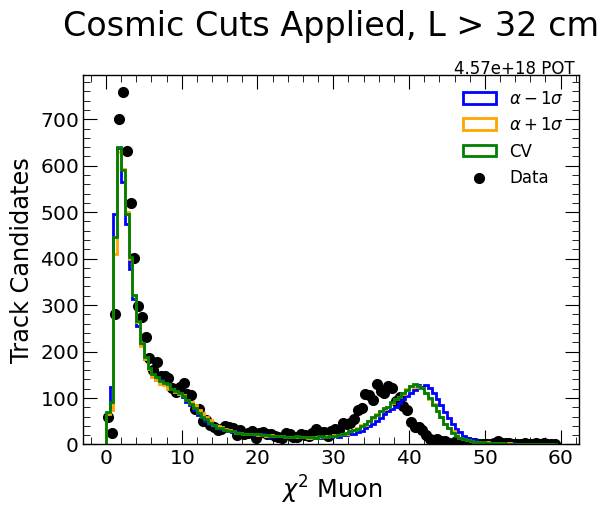

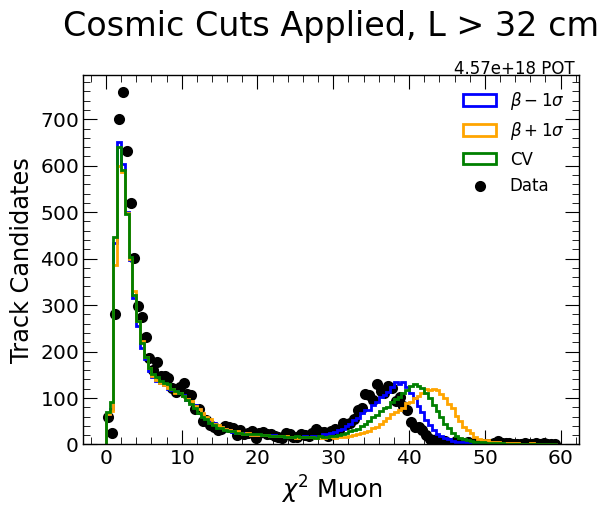

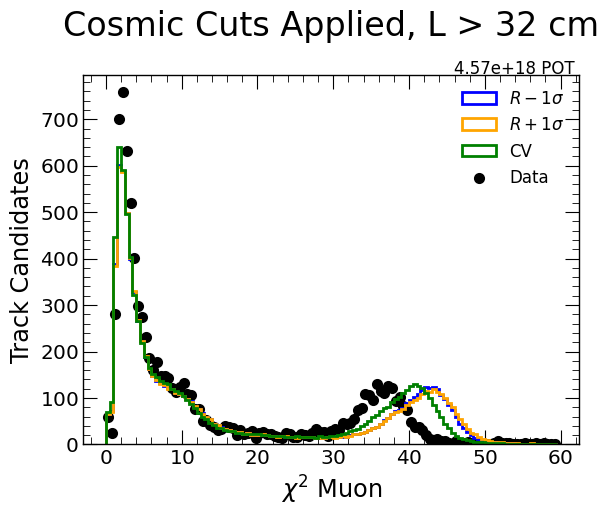

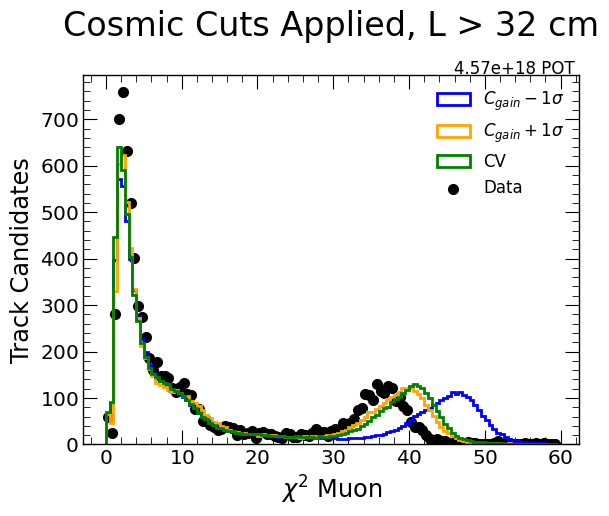

In [29]:
#Muon chi2
chi2_bins = np.arange(0,60,0.5)
fig1,ax1 = plt.subplots()
fig2,ax2 = plt.subplots()
fig3,ax3 = plt.subplots()
fig4,ax4 = plt.subplots()
for i,(col,label,color) in enumerate(zip(alpha_muon_cols,alpha_labels,colors)):
  ax1.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(beta_muon_cols,beta_labels,colors)):
  ax2.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(r_muon_cols,r_labels,colors)):
  ax3.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(gain_muon_cols,gain_labels,colors)):
  ax4.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
#Data
counts, bin_edges = np.histogram(trk_data_nocosmic.data.pfp.trk.chi2pid.I2.chi2_muon, 
                                  bins=chi2_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
for ax in (ax1,ax2,ax3,ax4):
  ax.scatter(bin_centers, counts, color='black', label='Data')
  ax.legend()
  ax.set_xlabel(r'$\chi^2$ Muon')
  ax.set_ylabel('Track Candidates')
  plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
  ax.set_title('Cosmic Cuts Applied, L > 32 cm')

fig1.show()
fig2.show()
fig3.show()
plotters.save_plot('chi2_muon_alpha',fig=fig1,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_muon_beta',fig=fig2,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_muon_R',fig=fig3,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_muon_gain',fig=fig4,folder_name=f'{PLOT_DIR}/chi2')

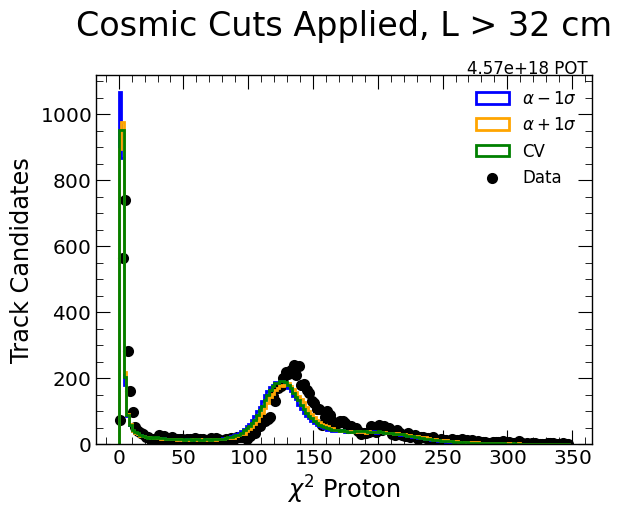

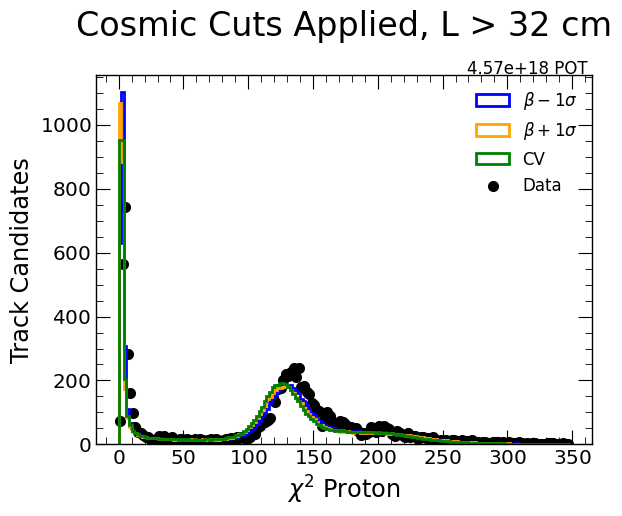

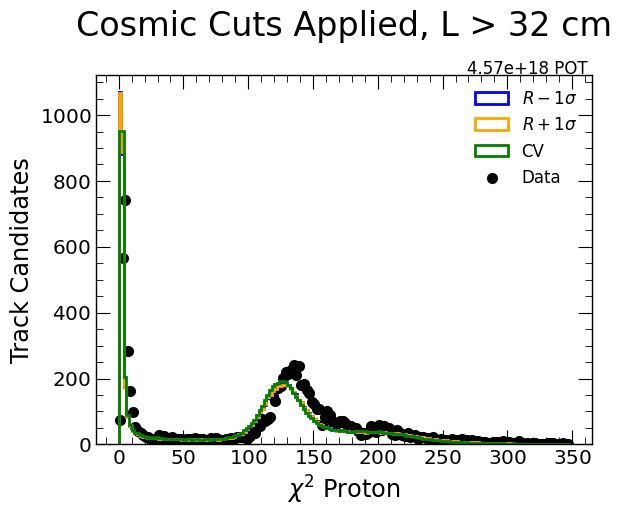

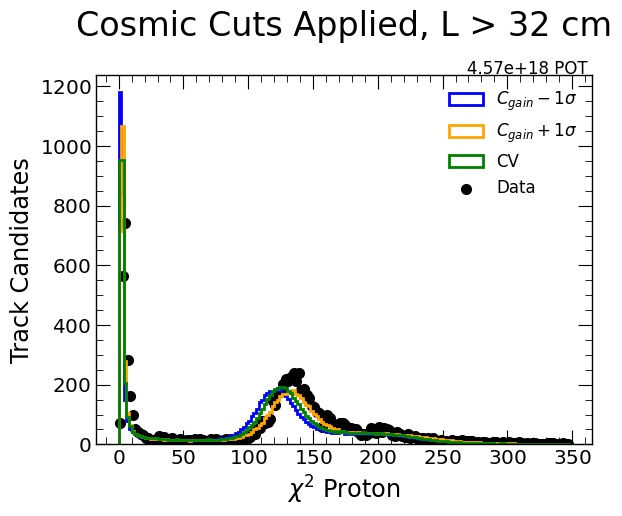

In [30]:
# Proton chi2
chi2_bins = np.arange(0,350,2)
fig1,ax1 = plt.subplots()
fig2,ax2 = plt.subplots()
fig3,ax3 = plt.subplots()
fig4,ax4 = plt.subplots()
for i,(col,label,color) in enumerate(zip(alpha_proton_cols,alpha_labels,colors)):
  ax1.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(beta_proton_cols,beta_labels,colors)):
  ax2.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(r_proton_cols,r_labels,colors)):
  ax3.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(gain_proton_cols,gain_labels,colors)):
  ax4.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
#Data
counts, bin_edges = np.histogram(trk_data_nocosmic.data.pfp.trk.chi2pid.I2.chi2_proton, 
                                  bins=chi2_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
for ax in (ax1,ax2,ax3,ax4):
  ax.scatter(bin_centers, counts, color='black', label='Data')
  ax.legend()
  ax.set_xlabel(r'$\chi^2$ Proton')
  ax.set_ylabel('Track Candidates')
  plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
  ax.set_title('Cosmic Cuts Applied, L > 32 cm')
fig1.show()
fig2.show()
fig3.show()
fig4.show()
plotters.save_plot('chi2_proton_alpha',fig=fig1,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_proton_beta',fig=fig2,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_proton_R',fig=fig3,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_proton_gain',fig=fig4,folder_name=f'{PLOT_DIR}/chi2')

## Testing

In [103]:
slc_mc.data.slc.vertex.x

__ntuple  entry  rec.slc..index
0         0      0                -155.903290
                 1                 -40.019745
                 2                 107.079849
                 3                 233.836166
                 4                 122.271393
                                      ...    
1999      11     200005            -33.353985
                 200006             17.986471
                 200007           -102.552795
                 200008            203.392349
                 200009            -13.184225
Name: x, Length: 888597, dtype: float32

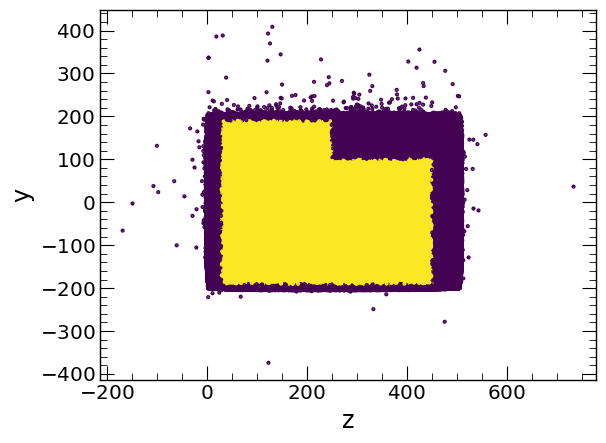

In [ ]:
mask = np.abs(slc_mc.data.slc.vertex.x) < 150
fig,ax = plt.subplots()
ax.scatter(slc_mc.data.slc.vertex.z[mask],
  slc_mc.data.slc.vertex.y[mask],
  c=slc_mc.data.vertex.fv[mask],
  cmap='viridis',
  s=1)
ax.set_xlabel('z')
ax.set_ylabel('y')
fig.show()

In [71]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v5/mc_tinypand_nosyst_nocuts_recomb.df'
#slc = CAFSlice.load(fname,key='evt_pand_0')
trk = PFP.load(fname,key='trk_0')
# _slc = slc.copy()
# _slc.remove_column_suffix('_alpha_emb00')
# list(_slc.data.keys())

In [68]:
pd.read_hdf(fname,key='trk_0')

pfp              \
                                                              trk               
                                                            start               
                                                                x           y   
                                                                                
                                                                                
__ntuple entry rec.slc..index rec.slc.reco.pfp..index                           
0        0     0              0                       -156.139526  -15.292214   
                              1                       -155.834457  -15.004409   
                              2                       -172.410919  -42.356522   
         1     0              0                         20.219536   82.494003   
               1              0                        -67.209717  157.315323   
         2     0              0                       -126.687546 -186.605728   
               1              0                         71.984909  -53.734390   
         3     0              0                       -161.129898 -159.782379   
         4     0              0                         84.376717  -42.759632   
               1              0                         81.371315 -157.385147   
                              1                         80.889984 -193.533142   
                              2                         91.863693 -200.485687   
               2              0                       -162.749908   10.348000   
                              1                       -162.610046   10.312423   
         5     0              0                        109.656174   99.204170   
               1              0                        -73.329697 -198.313019   
                              1                        -76.242920 -197.817169   
                              2                        -73.614334 -196.824448   
         6     0              0                       -107.854507  -99.395508   
               1              1                         -1.901666  135.763397   
               2              0                       -180.710480  185.264313   
               3              2                       -104.591476  121.698883   
                              3                       -104.520126  121.830307   
         7     0              0                        -68.111000   78.195557   
                              1                        -69.010063   78.087502   
               1              0                        155.727020 -109.943832   
         8     0              0                        160.403641   13.735312   
         9     0              0                       -188.851288  173.579697   
                              1                       -188.702362  173.019226   
         10    0              0                         22.611639   29.091284   
                              1                         23.565468   51.924099   
                              2                         21.858974   18.093592   
         11    0              0                        172.908524  -42.543655   
               1              0                         38.891392  198.624405   
         12    0              0                       -172.355392   79.800781   
               1              0                        -95.926849  -27.073606   
                              1                        -96.507652  -27.796011   
                              3                        -97.101662  -27.971813   
                              4                        -96.091492  -26.453979   
               2              0                        -65.992882  196.726456   
         13    0              0                         -9.996276  -38.225296   
               1              0                         95.686272  201.719757   
         14    0              0                        -61.938705 -202.236908   
            

In [67]:
trk.data

AttributeError: 'NoneType' object has no attribute 'data'

In [63]:
trk.data

AttributeError: 'NoneType' object has no attribute 'data'

In [58]:
from sbnd.general.utils import h5py_file_xrootd
with h5py_file_xrootd(fname) as f:
  print(list(f.keys()))

['evt_pand_0', 'hdr_0', 'histgenevtdf_0', 'histpotdf_0', 'mcnu_0', 'split', 'trk_0']


In [51]:
trk

In [ ]:
list(slc.data.keys())
#str(slc.data.keys()[0][1:])

[('slc', 'is_clear_cosmic', '', '', '', '', '', '', ''),
 ('slc', 'vertex', 'x', '', '', '', '', '', ''),
 ('slc', 'vertex', 'y', '', '', '', '', '', ''),
 ('slc', 'vertex', 'z', '', '', '', '', '', ''),
 ('slc', 'tmatch', 'eff', '', '', '', '', '', ''),
 ('slc', 'tmatch', 'pur', '', '', '', '', '', ''),
 ('slc', 'tmatch', 'idx', '', '', '', '', '', ''),
 ('slc', 'nu_score', '', '', '', '', '', '', ''),
 ('slc', 'barycenterFM', 'flashTime', '', '', '', '', '', ''),
 ('slc', 'barycenterFM', 'score', '', '', '', '', '', ''),
 ('slc', 'barycenterFM', 'flashPEs', '', '', '', '', '', ''),
 ('slc', 'opt0', 'score', '', '', '', '', '', ''),
 ('slc', 'opt0', 'time', '', '', '', '', '', ''),
 ('slc', 'reco', 'npfp', '', '', '', '', '', ''),
 ('slc', 'reco', 'nstub', '', '', '', '', '', ''),
 ('slc', 'truth', 'E', '', '', '', '', '', ''),
 ('slc', 'truth', 'time', '', '', '', '', '', ''),
 ('slc', 'truth', 'bjorkenX', '', '', '', '', '', ''),
 ('slc', 'truth', 'inelasticityY', '', '', '', '', ''

In [42]:
CALO_KEEP_KEYS = [('pfp', 'trackScore', '', '', '', '', '', ''), ('pfp', 'trk', 'chi2pid', 'I2', 'chi2_muon', '', '', ''), ('pfp', 'trk', 'chi2pid', 'I2', 'chi2_proton', '', '', '')]

In [43]:
[len(k) for k in CALO_KEEP_KEYS]

[8, 8, 8]

In [41]:
len(('pfp', 'trackScore', '', '', '', '', '', ''))# in CALO_KEEP_KEYS

8

In [39]:
len(('pfp', 'trackScore', '', '', '', '', '', ''))

8

In [24]:
slc.data.cut.flashpe

__ntuple  entry  rec.slc..index
0         0      0                  True
                 1                  True
                 2                  True
                 3                 False
                 4                 False
                                   ...  
          15     6                  True
                 7                  True
                 8                  True
                 9                  True
                 10                 True
Name: flashpe, Length: 151, dtype: bool

In [5]:
fname = '/exp/sbnd/data/users/brindenc/trash/dumbaf.root'
tree = uproot.open(fname)['recTree']
keys = ['rec.slc.barycenterFM.flashPEs','rec.slc.barycenterFM.flashTime']

In [7]:
[k for k in tree.keys() if 'barycenterFM' in k]

['rec.slc.barycenterFM.chargeCenter.x',
 'rec.slc.barycenterFM.chargeCenter.y',
 'rec.slc.barycenterFM.chargeCenter.z',
 'rec.slc.barycenterFM.chargeCenterXLocal',
 'rec.slc.barycenterFM.chargeTotal',
 'rec.slc.barycenterFM.chargeWidth.x',
 'rec.slc.barycenterFM.chargeWidth.y',
 'rec.slc.barycenterFM.chargeWidth.z',
 'rec.slc.barycenterFM.chi2',
 'rec.slc.barycenterFM.deltaT',
 'rec.slc.barycenterFM.deltaY',
 'rec.slc.barycenterFM.deltaY_Trigger',
 'rec.slc.barycenterFM.deltaZ',
 'rec.slc.barycenterFM.deltaZ_Trigger',
 'rec.slc.barycenterFM.flashAsymmetry',
 'rec.slc.barycenterFM.flashCenter.x',
 'rec.slc.barycenterFM.flashCenter.y',
 'rec.slc.barycenterFM.flashCenter.z',
 'rec.slc.barycenterFM.flashFirstHit',
 'rec.slc.barycenterFM.flashPEs',
 'rec.slc.barycenterFM.flashTime',
 'rec.slc.barycenterFM.flashWidth.x',
 'rec.slc.barycenterFM.flashWidth.y',
 'rec.slc.barycenterFM.flashWidth.z',
 'rec.slc.barycenterFM.overlapY',
 'rec.slc.barycenterFM.overlapZ',
 'rec.slc.barycenterFM.radius

In [8]:
df = tree.arrays(keys,library='pd')

In [12]:
df.iloc[0][0],df.iloc[0][1]

/tmp/ipykernel_357130/3770073387.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][0],df.iloc[0][1]


(<Array [3.03e+04, 3.03e+04, 3.03e+04, 195, 195] type='5 * float64'>,
 <Array [1.46, 1.46, 1.46, 2.79, 2.79] type='5 * float64'>)

In [413]:
fname = '/exp/sbnd/data/users/apapadop/dfs/v10_14_00/data_MCP2025C_FallValidationII_offbnblight_v10_14_00_flatcaf_sbnd.df'
fname = MC_FNAME
with h5py.File(fname, 'r') as f:
  keys = list(f.keys())
print(keys)

['evt_pand_0', 'hdr_0', 'histgenevtdf_0', 'histpotdf_0', 'mcnu_0', 'split', 'trk_0']


In [415]:
df = pd.read_hdf(fname,key='histpotdf_0')
df.TotalPOT.values.sum()

1378889283925906.8

In [36]:
df.noffbeambnb.values.sum()

1661243.0